# ETFs — Exploratory Data Analysis

**Docker image**: `ml4t`

**Purpose**: Profile the 100-ETF universe sourced from Yahoo Finance and confirm the
group coverage, history, and data-quality characteristics that drive the ETF rotation
case study.

**Learning objectives**:

- Load the ETF panel via `data.load_etfs` and inspect its canonical schema.
- Quantify per-symbol coverage and see why this universe *grows and plateaus*
  rather than rising and falling (contrast `01_us_equities_eda`).
- Attach the nine-group classification from the universe dictionary and check the
  panel and dictionary agree symbol-for-symbol.
- Check OHLC invariants and null rates, and compare liquidity across the nine groups.

**Book reference**: §2.2 ("The Asset-Class Market Data Landscape" — ETPs).

**Prerequisites**: `data` package on `PYTHONPATH`; ETF parquet present at
`ML4T_DATA_PATH/etfs/market/`. Run `python data/etfs/market/download.py` if missing.

In [1]:
"""ETFs — Exploratory data analysis of the multi-asset ETF universe."""

import plotly.graph_objects as go
import polars as pl
from ml4t.data.etfs import ETFDataManager

from data import load_etfs
from utils.data_quality import check_ohlc_invariants
from utils.paths import REPO_ROOT
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

## 1. Load and inspect

The ETF universe is stored as a single Parquet file of daily OHLCV data for
**100 ETFs** spanning the major asset classes.

In [3]:
etfs = load_etfs()

print("=== ETF dataset ===")
print(f"Shape: {etfs.shape}")
print(f"Columns: {etfs.columns}")

=== ETF dataset ===
Shape: (470662, 7)
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'symbol']


In [4]:
# Schema overview
print("\nSchema:")
for col, dtype in etfs.schema.items():
    print(f"  {col}: {dtype}")


Schema:
  timestamp: Date
  open: Float64
  high: Float64
  low: Float64
  close: Float64
  volume: Float64
  symbol: String


### Adjusted prices

Yahoo Finance returns split- and dividend-adjusted OHLC. The `close` column is the
adjusted close, so returns can be computed directly without a separate `adj_close`
column. This is the opposite convention to the US equities panel in
`01_us_equities_eda`, which ships raw *and* adjusted columns — worth keeping straight
when you move between the two.

## 2. Coverage

How many ETFs, over what window, and how much of it does each one cover?

In [5]:
symbols = etfs["symbol"].unique().sort().to_list()
date_range = etfs.select(
    pl.col("timestamp").min().alias("start"),
    pl.col("timestamp").max().alias("end"),
    pl.col("timestamp").n_unique().alias("unique_dates"),
)
full_start = date_range["start"][0]
full_end = date_range["end"][0]

print("=== Coverage ===")
print(f"Number of ETFs: {len(symbols)}")
print(f"Date range:     {full_start} to {full_end}")
print(f"Trading days:   {date_range['unique_dates'][0]:,}")

=== Coverage ===
Number of ETFs: 100
Date range:     2006-01-03 to 2025-12-31
Trading days:   5,031


In [6]:
# Per-symbol first/last observation and row count
symbol_stats = etfs.group_by("symbol").agg(
    pl.col("timestamp").min().alias("start"),
    pl.col("timestamp").max().alias("end"),
    pl.len().alias("rows"),
)
partial = symbol_stats.filter((pl.col("start") != full_start) | (pl.col("end") != full_end))

print(f"Symbols with full coverage:    {symbol_stats.height - partial.height}")
print(f"Symbols with partial coverage: {partial.height}")

Symbols with full coverage:    59
Symbols with partial coverage: 41


Most ETFs predate the 2006 start of the panel; a sizeable minority were launched
later and so start after `2006-01-03`. None *end* early — every symbol is still
quoted on the final date.

In [7]:
partial.select(["symbol", "start", "end", "rows"]).sort("start")

symbol,start,end,rows
str,date,date,u32
"""DBC""",2006-02-06,2025-12-31,5008
"""XBI""",2006-02-06,2025-12-31,5008
"""USO""",2006-04-10,2025-12-31,4964
"""SLV""",2006-04-28,2025-12-31,4951
"""VIG""",2006-05-02,2025-12-31,4949
…,…,…,…
"""MTUM""",2013-04-18,2025-12-31,3197
"""BNDX""",2013-06-04,2025-12-31,3165
"""QUAL""",2013-07-18,2025-12-31,3134


### The universe grows and then plateaus

Counting how many ETFs have data available at each year-end tells a very different
story from the equities panel in `01_us_equities_eda`. There, the count rose for
fifty years and then *fell* — the signature of a data-collection artifact, not a
market. Here it rises to 100 and stays there: a curated universe, held fixed, with
new products phased in as they launch.

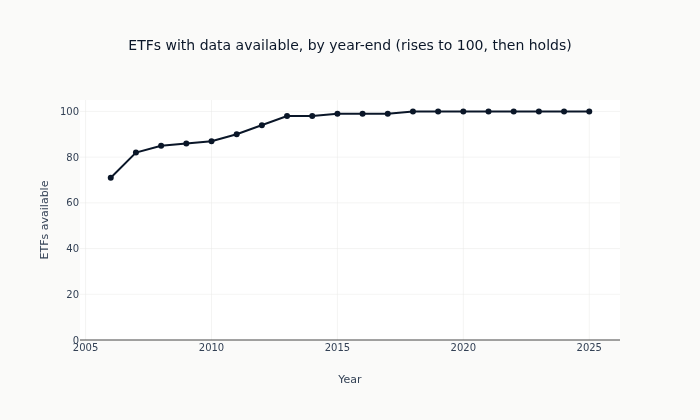

In [8]:
years = list(range(full_start.year, full_end.year + 1))
available = [
    symbol_stats.filter((pl.col("start").dt.year() <= y) & (pl.col("end").dt.year() >= y)).height
    for y in years
]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=years,
        y=available,
        mode="lines+markers",
        name="ETFs available",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.update_layout(
    title="ETFs with data available, by year-end (rises to 100, then holds)",
    xaxis_title="Year",
    yaxis_title="ETFs available",
    yaxis_range=[0, 105],
    height=420,
)
fig.show()

## 3. The nine groups

The universe config that drove the download — `data/etfs/market/config.yaml`, read
through `ETFDataManager` — classifies every symbol into one of **nine groups**. Sourcing
the classification from the same config that generated the panel (rather than a separate
metadata file) keeps the two in lockstep by construction; we still cross-check that the
configured universe and the price panel agree symbol-for-symbol.

In [9]:
config_path = REPO_ROOT / "data" / "etfs" / "market" / "config.yaml"
etf_mgr = ETFDataManager.from_config(str(config_path))

groups = pl.DataFrame(
    [
        {"symbol": symbol, "group": group, "description": info.get("description", "")}
        for group, info in etf_mgr.config.tickers.items()
        for symbol in info["symbols"]
    ]
)

panel_symbols = set(symbols)
config_symbols = set(groups["symbol"].to_list())
print("=== Panel vs config universe ===")
print(f"In panel but not config: {sorted(panel_symbols - config_symbols) or 'none'}")
print(f"In config but not panel: {sorted(config_symbols - panel_symbols) or 'none'}")

group_sizes = groups.group_by("group").agg(pl.len().alias("etfs")).sort("etfs", descending=True)
print(f"\nGroups: {group_sizes.height} | ETFs classified: {group_sizes['etfs'].sum()}")
group_sizes

=== Panel vs config universe ===
In panel but not config: none
In config but not panel: none

Groups: 9 | ETFs classified: 100


group,etfs
str,u32
"""international_developed""",18
"""fixed_income""",15
"""us_sectors""",13
"""emerging_markets""",11
"""us_equity_broad""",10
"""us_equity_style""",10
"""specialty""",10
"""commodities""",9
"""currency""",4


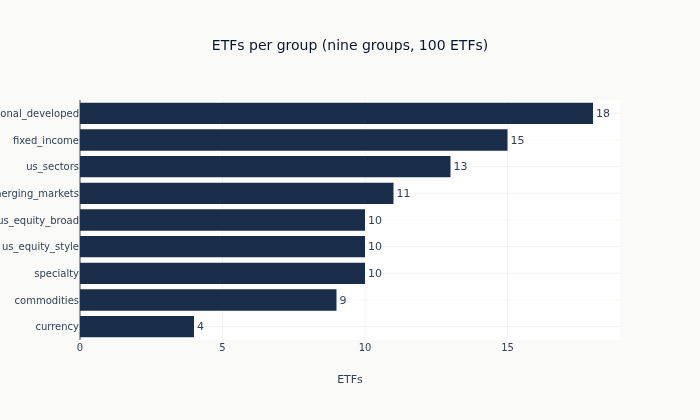

In [10]:
fig = go.Figure(
    go.Bar(
        x=group_sizes["etfs"].to_list(),
        y=group_sizes["group"].to_list(),
        orientation="h",
        marker_color=COLORS["slate"],
        text=group_sizes["etfs"].to_list(),
        textposition="outside",
    )
)
fig.update_layout(
    title="ETFs per group (nine groups, 100 ETFs)",
    xaxis_title="ETFs",
    yaxis=dict(autorange="reversed"),
    height=420,
)
fig.show()

## 4. Data quality

In [11]:
null_counts = etfs.null_count()
total_nulls = null_counts.sum_horizontal()[0]
zero_volume = etfs.filter(pl.col("volume") == 0)

print("=== Data quality ===")
print(f"Total null values: {total_nulls}")
print(f"Zero-volume rows:  {zero_volume.height} ({100 * zero_volume.height / etfs.height:.3f}%)")

=== Data quality ===
Total null values: 0
Zero-volume rows:  158 (0.034%)


In [12]:
# OHLC invariants: high should be the max and low the min of {open, high, low, close}
invariants = check_ohlc_invariants(etfs)
print("OHLC invariants:")
for row in invariants.iter_rows(named=True):
    status = "[OK]" if row["valid_pct"] >= 99.99 else "[WARN]"
    print(f"  {status} {row['check']}: {row['valid_pct']:.2f}%")

violations = etfs.filter(
    (pl.col("high") < pl.col("low"))
    | (pl.col("high") < pl.col("open"))
    | (pl.col("high") < pl.col("close"))
    | (pl.col("low") > pl.col("open"))
    | (pl.col("low") > pl.col("close"))
)
print(
    f"\nTotal OHLC violations: {violations.height} ({100 * violations.height / etfs.height:.3f}%)"
)

OHLC invariants:
  [OK] high_gte_low: 100.00%
  [OK] high_gte_open: 100.00%
  [WARN] high_gte_close: 99.90%
  [OK] low_lte_open: 100.00%
  [WARN] low_lte_close: 99.94%
  [OK] volume_non_negative: 100.00%

Total OHLC violations: 760 (0.161%)


The handful of violations are `high < close` or `low > close` after price adjustment.
The same cumulative split/dividend ratio is applied to all four price fields, but
small per-field rounding can break invariants that the raw quotes satisfied. At about
a sixth of a percent of rows they are immaterial for return and feature calculations,
but worth knowing about before computing intraday-range statistics.

## 5. Liquidity across the groups

Average daily volume varies by more than an order of magnitude across groups. That
spread drives transaction-cost assumptions in later chapters: a rotation that trades
the currency bucket cannot assume the fills a broad-equity bucket gets.

In [13]:
by_group_vol = (
    etfs.join(groups.select(["symbol", "group"]), on="symbol", how="left")
    .group_by("group")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("avg_volume", descending=True)
)

print("=== Average daily volume by group ===")
for row in by_group_vol.iter_rows(named=True):
    print(f"  {row['group']:<24} {row['avg_volume']:>14,.0f} shares/day")

=== Average daily volume by group ===
  us_equity_broad              25,496,479 shares/day
  us_sectors                   19,046,202 shares/day
  emerging_markets             12,719,136 shares/day
  fixed_income                  4,716,412 shares/day
  commodities                   4,463,106 shares/day
  specialty                     4,416,722 shares/day
  international_developed       3,742,462 shares/day
  us_equity_style               1,322,227 shares/day
  currency                        616,466 shares/day


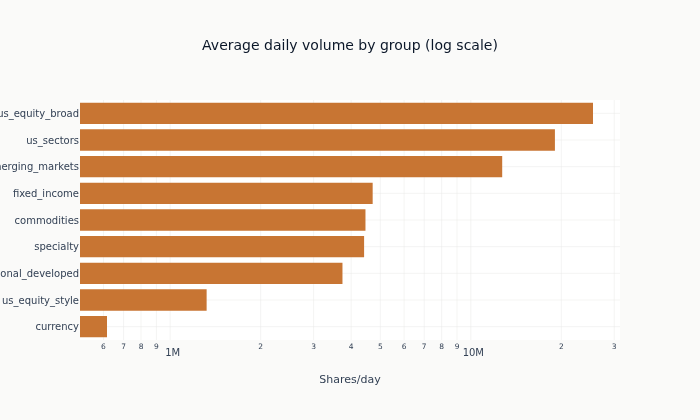

In [14]:
fig = go.Figure(
    go.Bar(
        x=by_group_vol["avg_volume"].to_list(),
        y=by_group_vol["group"].to_list(),
        orientation="h",
        marker_color=COLORS["copper"],
    )
)
fig.update_layout(
    title="Average daily volume by group (log scale)",
    xaxis_title="Shares/day",
    xaxis_type="log",
    yaxis=dict(autorange="reversed"),
    height=420,
)
fig.show()

## 6. Price levels

ETF price levels span a wide range — from single digits to several thousand dollars —
which is why later work compares *returns*, not price levels, across the universe.

In [15]:
latest = etfs.filter(pl.col("timestamp") == full_end)
price_dist = latest.select(
    pl.col("close").min().alias("min_price"),
    pl.col("close").max().alias("max_price"),
    pl.col("close").median().alias("median_price"),
    pl.col("close").mean().alias("mean_price"),
)
print("=== Price distribution (latest date) ===")
price_dist

=== Price distribution (latest date) ===


min_price,max_price,median_price,mean_price
f64,f64,f64,f64
12.26,680.062744,86.874882,127.252057


## 7. Loading a subset or using the ml4t-data library

`load_etfs(symbols=[...])` filters the panel to a subset; `ETFDataManager` (loaded in
§3) is the config-driven entry point used by the production download/refresh workflow in
`data/etfs/market/`.

In [16]:
spy = load_etfs(symbols=["SPY"])
print(f"SPY via loader: {spy.shape}")

SPY via loader: (5031, 7)


In [17]:
configured = sum(len(group["symbols"]) for group in etf_mgr.config.tickers.values())
print(f"ETFDataManager loaded from {config_path}")
print(f"  Provider:           {etf_mgr.config.provider}")
print(f"  Date range:         {etf_mgr.config.start} to {etf_mgr.config.end}")
print(f"  Configured symbols: {configured} across {len(etf_mgr.config.tickers)} groups")

ETFDataManager loaded from /home/stefan/ml4t/code/data/etfs/market/config.yaml
  Provider:           yahoo
  Date range:         2006-01-01 to 2025-12-31
  Configured symbols: 100 across 9 groups


## Key takeaways

**What this notebook does.** It establishes what is in the ETF file — how many ETFs,
over what window, grouped how — and confirms the price panel and the group dictionary
describe the same 100 symbols.

**What it finds.**

1. **Pre-adjusted prices.** The `close` column is the split- and dividend-adjusted
   close; return calculations need no further adjustment.
2. **Coverage.** 100 ETFs, daily, `2006-01-03` to `2025-12-31` (5,031 trading days).
   59 span the full window; 41 start later as new products launched. None end early.
3. **A curated universe, not a collection artifact.** The available-ETF count rises to
   100 and plateaus — the inverse of the equities panel's rise-and-fall.
4. **Nine groups, 100 ETFs.** The universe config classifies every symbol; the panel
   and config agree symbol-for-symbol, with no members in one and not the other.
5. **Mostly clean.** Zero nulls, 158 zero-volume rows, and 760 OHLC violations
   (0.16% of rows) from post-adjustment rounding — immaterial for returns and features.
6. **Liquidity spans an order of magnitude.** Broad US equity averages ~25M
   shares/day and the currency bucket ~0.6M — a ~41× spread that later chapters must
   respect when modeling transaction costs.

**What it means.** This is a clean, curated, survivorship-*aware* panel: unlike the
equities panel, the universe is fixed and every symbol is still quoted, so there is no
hidden exit record to reconstruct. The work in Chapter 6 filters this 100-ETF pool
into the trading universe the rotation case study uses.

### Next steps

- **`13_data_quality_framework`**: systematic data-quality checks across the datasets.
- **`15_survivorship_bias_detection`**: survivorship and selection bias in the equity
  panel — the contrast to the clean ETF universe shown here.
- **Chapter 6**: universe construction over this 100-ETF candidate pool.